<a href="https://colab.research.google.com/github/LucasSLDantas/Matrix_de_metricas_ML/blob/main/matrix_de_metricas_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
# Verifica a versão do TensorFlow
print(tf.__version__)

2.18.0


In [ ]:
# Ativa o TensorBoard em notebooks Jupyter
%load_ext tensorboard

In [ ]:
# Define o diretório de log para o TensorBoard
logdir = 'log'

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0

classes = [0,1,2,3,4,5,6,7,8,9]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x=train_images,
          y=train_labels,
          epochs=5,
          validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 36ms/step - accuracy: 0.9008 - loss: 0.3230 - val_accuracy: 0.9857 - val_loss: 0.0464
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.9850 - loss: 0.0495 - val_accuracy: 0.9867 - val_loss: 0.0401
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 31ms/step - accuracy: 0.9895 - loss: 0.0336 - val_accuracy: 0.9888 - val_loss: 0.0342
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9925 - loss: 0.0242 - val_accuracy: 0.9891 - val_loss: 0.0362
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 32ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9892 - val_loss: 0.0347


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


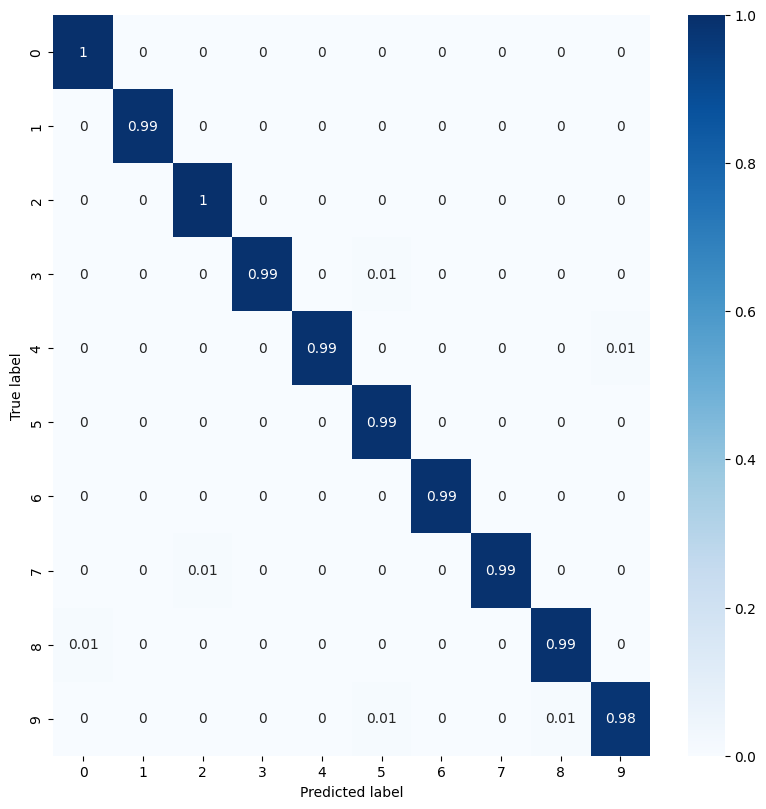

In [ ]:
y_true = test_labels
y_pred = model.predict(test_images)

classes = [0,1,2,3,4,5,6,7,8,9]

# Convert predictions to class labels
y_pred_labels = np.argmax(y_pred, axis=1) # Get the index of the highest probability

con_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred_labels).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                          index=classes,
                          columns=classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

classes = range(10)          # 0 … 9
metrics_list = []

for cls in classes:
    TP = con_mat[cls, cls]                   # Diagonal
    FN = con_mat[cls].sum() - TP             # Linha (erros da classe)
    FP = con_mat[:, cls].sum() - TP          # Coluna (confundidos com a classe)
    TN = con_mat.sum() - (TP + FN + FP)      # Todo o resto

    sens   = TP / (TP + FN) if TP + FN else 0   # recall
    spec   = TN / (TN + FP) if TN + FP else 0
    prec   = TP / (TP + FP) if TP + FP else 0
    f1     = 2 * prec * sens / (prec + sens) if prec + sens else 0
    acc    = (TP + TN) / con_mat.sum()

    metrics_list.append(
        dict(classe=cls,
             sensibilidade=sens,
             especificidade=spec,
             precisao=prec,
             f_score=f1,
             acuracia=acc)
    )

df_metrics = pd.DataFrame(metrics_list).set_index('classe')
print(df_metrics.round(3))

        sensibilidade  especificidade  precisao  f_score  acuracia
classe                                                            
0               0.997           0.998     0.986    0.991     0.998
1               0.993           0.999     0.996    0.994     0.999
2               0.997           0.998     0.984    0.990     0.998
3               0.986           1.000     0.997    0.992     0.998
4               0.988           0.999     0.995    0.991     0.998
5               0.992           0.998     0.978    0.985     0.997
6               0.990           0.999     0.994    0.992     0.998
7               0.985           0.999     0.989    0.987     0.997
8               0.988           0.998     0.985    0.986     0.997
9               0.976           0.999     0.988    0.982     0.996
